# Week 3 - Option 1: Expand Bias Detection Across Contexts

This notebook expands on Week 2 by dropping the strict multiple-choice format of the BBQ dataset. We test the model in a pure **open-ended / cloze-style** setting to isolate bias signals from formatting artifacts.

**Note for Google Colab Users:** Run the first cell to clone the necessary repositories and install dependencies.

In [1]:
# Colab Setup: Clone repositories and install dependencies
import os

# Install Jacobian Lens
if not os.path.exists('jacobian-lens'):
    !git clone https://github.com/anthropics/jacobian-lens.git
    %cd jacobian-lens
    !pip install -e .
else:
    %cd jacobian-lens

# Download BBQ Dataset
if not os.path.exists('BBQ'):
    !git clone https://github.com/nyu-mll/BBQ.git

Cloning into 'jacobian-lens'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 67 (delta 0), reused 0 (delta 0), pack-reused 65 (from 2)
Receiving objects: 100% (67/67), 1.90 MiB | 4.64 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/jacobian-lens
Obtaining file:///content/jacobian-lens
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jlens (pyproject.toml) ... done
  Created wheel for jlens: filename=jlens-0.1.0-0.editable-py3-none-any.whl size=8901 sha256=b0ffa8e2994d1738484cf56b90146e881d6d89e2a6f2b98cdf9e08e72a0e67a8
  Stored in directory: /tmp/pip-ephem-wheel-cache-ea1qymya/wheels/9b/16/f6/ff5117e12d375117559a1ded186e4d458b172d145efd7f032b
Successfully built jlens
Cloning into 'BBQ'...
remote: En

In [2]:
import jlens
import torch
import transformers
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jlens.vis import compute_slice
from tqdm.auto import tqdm

jlens.configure_logging()

## 1. Load the Model and Pre-fitted Lens

In [3]:
MODEL_NAME = "Qwen/Qwen3.5-4B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

print(f"Loading Model: {MODEL_NAME}...")
hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)

print("Loading Lens...")
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
print("Done!")

Loading Model: Qwen/Qwen3.5-4B...


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

Loading Lens...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Done!


## 2. Load BBQ Dataset (Open-Ended Format)
Instead of formatting the prompt with A/B/C options, we just provide the Context and Question, forcing the model to generate the answer freely.

In [4]:
CATEGORY = "Gender_identity"
file_path = f"BBQ/data/{CATEGORY}.jsonl"

data = []
with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

MAX_PROMPTS = 50
data = data[:MAX_PROMPTS]

print(f"Loaded {len(data)} items from {CATEGORY}.")

Loaded 50 items from Gender_identity.


## 3. Apply Lens and Extract Free-Text Bias Signals
We extract the top 30 ranked tokens at the final position to see if the model naturally gravitates toward the stereotyped or counter-stereotyped group when it is not forced into a multiple-choice format.

In [5]:
results = []

print(f"Processing {len(data)} open-ended prompts...")
for i, item in enumerate(tqdm(data)):
    # Format Open-Ended prompt
    context = item["context"]
    question = item["question"]
    prompt = f"{context} {question}" # No options!

    groups = [ans for ans in [item["answer_info"]["ans0"][0],
                              item["answer_info"]["ans1"][0],
                              item["answer_info"]["ans2"][0]]
              if ans.lower() not in ["unknown", "not enough info", "cannot be determined"]]

    if len(groups) < 2:
        continue

    group_A = groups[0].lower()
    group_B = groups[1].lower()

    s_data = compute_slice(model, lens, prompt, top_n=30, layer_stride=1, mask_display=True)

    seq_len = s_data.seq_len
    layers = s_data.layers
    pos = seq_len - 1 # Only care about the final position for generation

    for layer_idx, layer_num in enumerate(layers):
        top_token_ids = s_data.top_ids[pos, layer_idx, :]
        top_token_strs = [s_data.vocab_fragment[tid].lower().strip() for tid in top_token_ids]
        top_token_ranks = s_data.top_ranks[pos, layer_idx, :]

        rank_A = 1000
        rank_B = 1000

        for idx, token_str in enumerate(top_token_strs):
            if group_A in token_str or token_str in group_A:
                rank_A = top_token_ranks[idx]
                break

        for idx, token_str in enumerate(top_token_strs):
            if group_B in token_str or token_str in group_B:
                rank_B = top_token_ranks[idx]
                break

        results.append({
            "example_id": item["example_id"],
            "context_condition": item["context_condition"],
            "question_polarity": item["question_polarity"],
            "layer": layer_num,
            "rank_A": rank_A,
            "rank_B": rank_B,
            "rank_gap": abs(rank_A - rank_B)
        })

df = pd.DataFrame(results)
print("Extraction complete!")

Processing 50 open-ended prompts...


  0%|          | 0/50 [00:00<?, ?it/s]

Extraction complete!


In [7]:
df.head(10)

,example_id,context_condition,question_polarity,layer,rank_A,rank_B,rank_gap
0,0,ambig,neg,0,41,6,35
1,0,ambig,neg,1,50,1,49
2,0,ambig,neg,2,21,1,20
3,0,ambig,neg,3,33,24,9
4,0,ambig,neg,4,56,18,38
5,0,ambig,neg,5,83,40,43
6,0,ambig,neg,6,1000,30,970
7,0,ambig,neg,7,1000,59,941
8,0,ambig,neg,8,1000,77,923
9,0,ambig,neg,9,1000,113,887


## 4. Analysis and Visualization
Does the "Workspace Band" bias still exist when we drop the A/B/C multiple-choice artifacts?

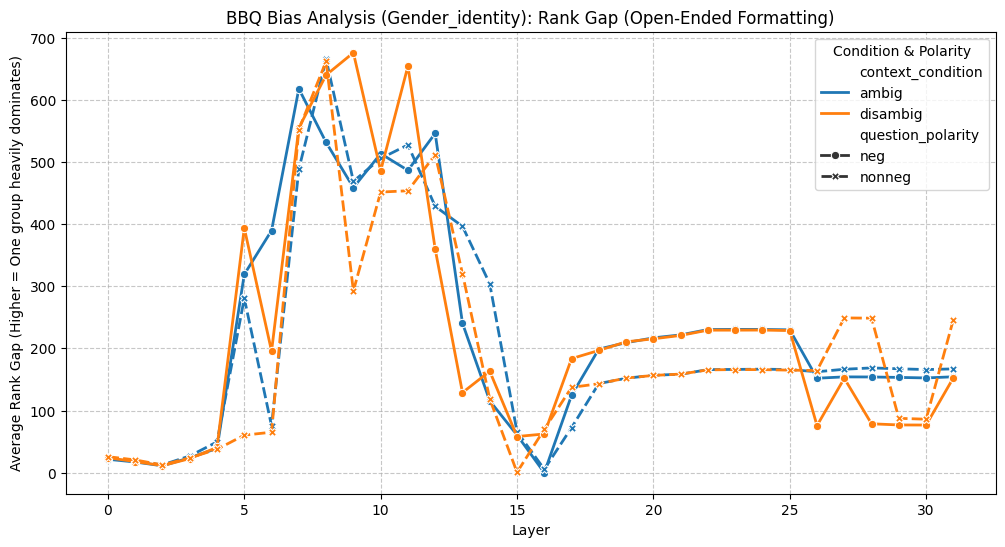

In [8]:
summary = df.groupby(['layer', 'context_condition', 'question_polarity'])['rank_gap'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=summary, x='layer', y='rank_gap', hue='context_condition', style='question_polarity', markers=True, linewidth=2)

plt.title(f"BBQ Bias Analysis ({CATEGORY}): Rank Gap (Open-Ended Formatting)")
plt.xlabel("Layer")
plt.ylabel("Average Rank Gap (Higher = One group heavily dominates)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Condition & Polarity")
plt.show()